# Past warm climates

In [1]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from scipy.signal import savgol_filter # for smoothing time series

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'
fontsize=9
plt.rcParams['font.size'] = fontsize

# Import the csv datasets:
# -----------------------
# Zachos data:
dir="/Users/eli/Courses/EPS101/Data-for-teaching-staff/Boxes/past-warm-climates/"
file="zachos2001.txt"
dataset = pd.read_fwf(dir+file,comment='#',verbose=True,infer_nrows=10000)
                     # ,delim_whitespace=False,na_values='NaN',skipinitialspace=True,skip_blank_lines=True,header=None)
data = dataset.iloc[:, :].values
#zachos_header = dataset.iloc[:, :].columns
genus=data[:,2]
a=data[:,1]
b=data[:,3]
zachos_years=a[b!=np.nan] # a[np.logical_and(b!=np.nan,genus!='CIB')]
zachos_d18O=16.5-4.3*b[b!=np.nan] # b[np.logical_and(b!=np.nan,genus!='CIB')]


# Pliocene east pacific data:
dir="/Users/eli/Courses/EPS101/Data-for-teaching-staff/Boxes/past-warm-climates/"
file="medina-elizalde2008-ODP847.txt"
dataset = pd.read_fwf(dir+file,comment='#')
#                      ,delim_whitespace=True,na_values='NaN',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
#header = dataset.iloc[:, :].columns
pliocene_east_years=np.asarray(data[:,0])
pliocene_east_SST=np.asarray(data[:,2])


# Pliocene west pacific data:
dir="/Users/eli/Courses/EPS101/Data-for-teaching-staff/Boxes/past-warm-climates/"
file="medina-elizalde2008-ODP806B.txt"
dataset = pd.read_fwf(dir+file,comment='#')
#                      ,delim_whitespace=True,na_values='NaN',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
#header = dataset.iloc[:, :].columns
pliocene_west_years=np.asarray(data[:,0])
pliocene_west_SST=np.asarray(data[:,2])

print("done loading libnraries and data.")

Filled 61 NA values in column 3.28
Filled 1466 NA values in column 0.88
Filled 5 NA values in column Unnamed: 5
Filled 488 NA values in column Unnamed: 6
done loading libnraries and data.


In [2]:
# smooth data:
zachos_d18O_smooth = savgol_filter(zachos_d18O, 5, 0) # window size , polynomial order 
pliocene_east_SST_smooth = savgol_filter(pliocene_east_SST, 11, 0) # window size , polynomial order 
pliocene_west_SST_smooth = savgol_filter(pliocene_west_SST, 11, 0) # window size , polynomial order 

print("done.")

done.


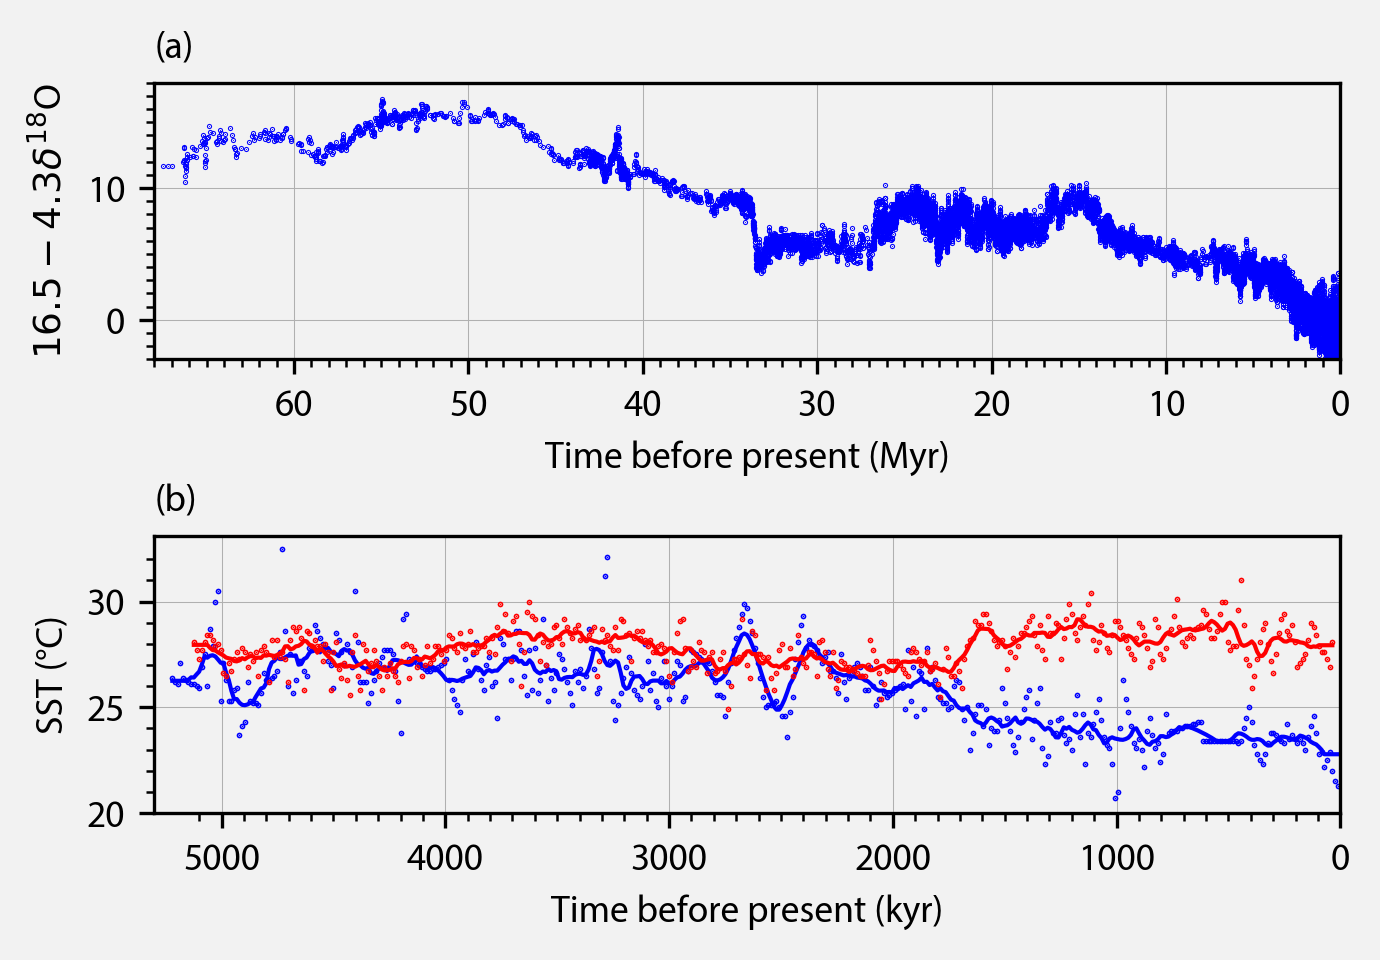

In [9]:
# plot

fig=plt.figure(figsize=(4.4,3),dpi=300)

plt.subplot(2,1,1)
#plt.plot(zachos_years,zachos_d18O,".",color='b',markersize=0.5)
plt.plot(zachos_years,zachos_d18O_smooth,marker=".",color='b',linestyle='none',markersize=0.5,fillstyle="full")
axes=plt.gca()
plt.xlabel("Time before present (Myr)")
#axes.invert_yaxis()
axes.set_xticks(np.arange(0,70,1), minor=True)
axes.set_yticks(np.arange(-10,20,1), minor=True)
plt.xlim(0,68)
plt.ylim(-3,18)
axes.invert_xaxis()
plt.ylabel("$16.5-4.3\\delta^{18}$O")
plt.grid(lw=0.25)
axes.set_facecolor('#f2f2f2')
plt.title("(a)",loc="left",fontsize=fontsize)


plt.subplot(2,1,2)
# East pacific
plt.plot(pliocene_east_years,pliocene_east_SST,marker=".",color='b',linestyle='none',markersize=0.75,fillstyle='full')
plt.plot(pliocene_east_years,pliocene_east_SST_smooth,"-",color='b',lw=1)

plt.plot(pliocene_west_years,pliocene_west_SST,marker=".",color='r',linestyle='none',markersize=0.75,fillstyle="full")
plt.plot(pliocene_west_years,pliocene_west_SST_smooth,"-",color='r',lw=1)
plt.xlim(0,5300)
#plt.ylim(24,29.3)
plt.gca().set_xticks(np.arange(0,5200,100), minor=True)
plt.gca().set_yticks(np.arange(20,33,1), minor=True)
axes=plt.gca()
axes.invert_xaxis()
plt.xlabel("Time before present (kyr)")
plt.ylabel("SST (°C)")
plt.grid(lw=0.25)
axes.set_facecolor('#f2f2f2')
plt.title("(b)",loc="left",fontsize=fontsize)

fig.patch.set_facecolor('#f2f2f2')

plt.tight_layout(h_pad=0.20,pad=0)

plt.show()
fig.savefig("Output/Box-past-warm-climates.pdf",facecolor='#f2f2f2')